# **Meshlands - Precipitation**
This notebook presents precipitation rate-related results and analysis. It is organized as:
- Total precipitation rate,
- Total snow rate,
- Subtropics focus (the rest of the planet being frozen, the subtropics focus allows a more precise analysis; however, the qualitative results are similar),
- Intra-cell comparison (quantitative comparison of local values of precipitation inside a unique land and/or ocean cell).

## **Initial Set Up-related**

### Imports

In [10]:
%matplotlib inline
import sys
sys.path.append('./scripts')

########## Plotting (Matplotlib) ##########
import matplotlib.pyplot as plt

########## Python Standard Library ##########
from copy import copy
import glob

########## Cartopy ##########
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point

########## Dask ##########
import dask

########## NumPy ##########
import numpy as np

########## SciPy ##########
import scipy.ndimage as ndi

########## Xarray ##########
import xarray as xr

### Function Definitions

In [11]:
# Overall: creates a new local mapping function that doesn't use basemap
def quick_map(mapdata,lat,lon,mesh,title=None,cb_ttl=None,cmap=None,clim=None,
              filepath=None,show=None,close=None,sigmask=None,p=None,
              do_zonal=None,
              outside_color = None, outside_val = None,extend='both'):
    '''
    creates a new local mapping function that does not use a basemap
    '''

    # Makes 2 subplots: one for map, one for zonal average next to it
    fig = plt.figure(figsize=(15,15))

    # Specifies a Robinson projection map
    ax = plt.axes(projection=ccrs.Robinson())

    # Collects the case mask data to plot coastlines
    xc_cyc = np.concatenate([mesh["xc"], mesh["xc"][:, :1] + 360], axis=1)
    yc_cyc = np.concatenate([mesh["yc"], mesh["yc"][:, :1]], axis=1)
    mask_cyc = np.concatenate([mesh["mask"], mesh["mask"][:, :1]], axis=1)

    # Draws coastlines
    ax.contour(xc_cyc,yc_cyc,mask_cyc,levels=[0.5],colors="black",linewidths=0.1,transform=ccrs.PlateCarree())
    
    # Sets the view to be the entire globe
    ax.set_global()

    # Creates a cyclic point to ensure longitude plots smoothly 
    cyclic_data, cyclic_lons = add_cyclic_point(mapdata,coord=lon)

    # Plots the data as a coloured mesh
    cs = plt.pcolormesh(cyclic_lons, lat, cyclic_data, transform=ccrs.PlateCarree())    
    
    # If a cmap (colour map) is specified, copy and use it
    # Else, copy and use the viridis cmap
    if cmap:
        plt.set_cmap(copy(cmap))
    else:
        plt.set_cmap(copy(plt.cm.viridis))

    # If a title is specified, use it (also sets the font size and position)
    if title:
        plt.title(title,fontsize=20,y=1.05)

    # If a clim (colour limit) is specified, use it
    if clim:
        plt.cm.ScalarMappable.set_clim(cs,vmin = clim[0],vmax = clim[1])

    # Sets the colour bar parameters
    cbar = plt.colorbar(ax=ax,orientation='horizontal',extend=extend,pad=.02, shrink=0.9)
    cbar.ax.tick_params(labelsize=15) 

    # If a cb_ttl (colour bar title) is specified, use it
    if cb_ttl:
        cbar.set_label(cb_ttl,fontsize=15)

    # Sets cm to the cmap
    cm = plt.get_cmap()
   
    # Overall: adds hatching for significance
    # If a p-value is specified, add 
    if p:

        # Creates a cyclic point to ensure longitude plots smoothly 
        cyclic_sig, cyclic_lons = add_cyclic_point(sigmask,coord=lon)

        # Creates a meshgrid using cyclic longitude and latitude coordinates
        CLN, CLT = np.meshgrid(cyclic_lons,lat)

        # Only puts the hatches where the sigmask is >0.5
        sigmask = np.where(cyclic_sig>p,1.0,np.nan)
        sigmask2 = np.ma.masked_where(cyclic_sig > p, sigmask)

        # Masks out insignificant latitude data
        lat_sig = np.ma.masked_where(cyclic_sig>p,CLT)

        # Masks out NaN latitude data
        lat_sig = np.ma.masked_where(np.isnan(cyclic_sig),lat_sig)

        # Masks out insignificant longitude data
        lon_sig = np.ma.masked_where(cyclic_sig>p,CLN)

        # Masks out NaN longitude data
        lon_sig = np.ma.masked_where(np.isnan(cyclic_sig),lon_sig)

        # Scatters markers
        hatch = ax.scatter(lon_sig,lat_sig,s=sigmask2,marker='x',#s=2,
                           c=[0.6, 0.6, 0.6],alpha=0.8,transform=ccrs.PlateCarree(),)

    # Add points at the center of each ocean group
    ocean_mask = (mesh['mask'] == 0)
    labeled_ocean, num_features = ndi.label(ocean_mask)
    lon_centers = []
    lat_centers = []
    for label in range(1, num_features + 1):
        y, x = ndi.center_of_mass(ocean_mask, labeled_ocean, label)
        # Interpolate coordinates assuming regular grid
        dlon = mesh['xc'][0, 1] - mesh['xc'][0, 0]
        dlat = mesh['yc'][1, 0] - mesh['yc'][0, 0]
        lon_center = mesh['xc'][0, 0] + x * dlon
        lat_center = mesh['yc'][0, 0] + y * dlat
        lon_centers.append(lon_center)
        lat_centers.append(lat_center)
    ax.scatter(lon_centers, lat_centers, marker='.', color='blue', s=5, transform=ccrs.PlateCarree())
    
    # Sets the alpha value
    ax.patch.set_alpha(0.0)

    # Add a line at the bottom of the plot to draw the separation with the following plot
    line = plt.Line2D([0.1, 1], [0.12, 0.12], transform=fig.transFigure, color='black')
    fig.add_artist(line)
    
    # If show is specified, show the plot
    if show:
        plt.show()

    # If filepath is specified, save the figured to the file path
    if filepath:
        fig.savefig(filepath+'.png',dpi=300,facecolor=None,edgecolor=None,bbox_inches='tight',transparent=True,pad_inches=0.01)

    # Closes the plot
    if close:
        plt.close()

    # Returns the figure
    return fig,ax,cs,cbar,cm

############

# Overall: creates a new local mapping function that doesn't use basemap
def quick_trop(mapdata,lat,lon,mesh,title=None,cb_ttl=None,cmap=None,clim=None,
              filepath=None,show=None,close=None,sigmask=None,p=None,
              do_zonal=None,
              outside_color = None, outside_val = None,extend='both'):
    '''
    variation of the quick_map function to only observe Tropics and Subtropics
    '''

    # Makes 2 subplots: one for map, one for zonal average next to it
    fig = plt.figure(figsize=(15,15))

    # Specifies a Robinson projection map
    ax = plt.axes(projection=ccrs.Robinson())

    # Collects the case mask data to plot coastlines
    xc_cyc = np.concatenate([mesh["xc"], mesh["xc"][:, :1] + 360], axis=1)
    yc_cyc = np.concatenate([mesh["yc"], mesh["yc"][:, :1]], axis=1)
    mask_cyc = np.concatenate([mesh["mask"], mesh["mask"][:, :1]], axis=1)

    # Draws coastlines
    ax.contour(xc_cyc,yc_cyc,mask_cyc,levels=[0.5],colors="black",linewidths=0.1,transform=ccrs.PlateCarree())
    
    # Sets the view to be the entire globe
    ax.set_extent([-170, -50, -30, 30], crs=ccrs.PlateCarree())

    # Creates a cyclic point to ensure longitude plots smoothly 
    cyclic_data, cyclic_lons = add_cyclic_point(mapdata,coord=lon)

    # Plots the data as a coloured mesh
    cs = plt.pcolormesh(cyclic_lons, lat, cyclic_data, transform=ccrs.PlateCarree())
    
    # If a title is specified, use it (also sets the font size and position)
    if title:
        plt.title(title,fontsize=16,y=1.05)

    # If a clim (colour limit) is specified, use it
    if clim:
        levels = np.linspace(clim[0], clim[1], 21)  # 21 bornes = 20 intervalles
        cs = plt.contourf(cyclic_lons, lat, cyclic_data, levels=levels, transform=ccrs.PlateCarree())
        if cmap:
            cs.set_cmap(copy(cmap))
        else:
            cs.set_cmap(copy(plt.cm.viridis))

    # Sets the colour bar parameters
    cbar = plt.colorbar(ax=ax,orientation='horizontal',extend=extend,pad=.02, shrink=0.9)
    cbar.ax.tick_params(labelsize=14) 

    # If a cb_ttl (colour bar title) is specified, use it
    if cb_ttl:
        cbar.set_label(cb_ttl,fontsize=14)

    # Sets cm to the cmap
    cm = plt.get_cmap()

    # Add points at the center of each ocean group
    ocean_mask = (mesh['mask'] == 0)
    labeled_ocean, num_features = ndi.label(ocean_mask)
    lon_centers = []
    lat_centers = []
    for label in range(1, num_features + 1):
        y, x = ndi.center_of_mass(ocean_mask, labeled_ocean, label)
        # Interpolate coordinates assuming regular grid
        dlon = mesh['xc'][0, 1] - mesh['xc'][0, 0]
        dlat = mesh['yc'][1, 0] - mesh['yc'][0, 0]
        lon_center = mesh['xc'][0, 0] + x * dlon
        lat_center = mesh['yc'][0, 0] + y * dlat
        lon_centers.append(lon_center)
        lat_centers.append(lat_center)
    ax.scatter(lon_centers, lat_centers, marker='.', color='blue', s=5, transform=ccrs.PlateCarree())
    
    # If show is specified, show the plot
    if show:
        plt.show()

    # If filepath is specified, save the figure to the file path
    if filepath:
        fig.savefig(filepath+'.png',dpi=300,facecolor=None,edgecolor=None,bbox_inches='tight',transparent=True,pad_inches=0.01)

    # Closes the plot
    if close:
        plt.close()

    # Returns the figure
    return fig,ax,cs,cbar,cm

##########

# Overall: calculates the global mean, ocean mean and land mean
def mean(ds_case,mask,var,var2=None):
    '''
    Calculates the global, ocean and land mean of a given variable for a given configuration.

    Args:
        ds_case (xarray): dictionary containing lat and lon dimensions.
        mask (list): representation of continental distribution, with value 1 if land and value 0 if ocean.
        var (str): name of the variable that needs to be averaged.

    Returns:
        gm (float OR array): global mean (can be an array if ds_case contains other dimensions).
        lm (float OR array): land mean (can be an array if ds_case contains other dimensions).
        om (float OR array): ocean mean (can be an array if ds_case contains other dimensions).
    '''
    if var2:
        mapdata = (ds_case[var].mean('year') + ds_case[var2].mean('year'))*86400*365.25*1000 #Convert to mm/yr
    else :
        mapdata = (ds_case[var].mean('year'))*86400*365.25*1000 #Convert to mm/yr
    
    # Weights the latitude, renames it to "weights", then prints the value
    weights = np.cos(np.deg2rad(ds_case[var].lat))
    weights.name = "weights"
    
    # Finds the weighted global mean based on latitude and longitude
    gm = mapdata.weighted(weights).mean(('lat', 'lon')).values

    # Defines a land timeseries where the land mask is present
    land = mapdata.where(mask == 1)

    # Defines an ocean timeseries where the land mask is not present (i.e. just ocean/water)
    ocean = mapdata.where(mask != 1)

    # Mean Land
    lm = land.weighted(weights).mean(('lat', 'lon')).values

    # Mean Ocean
    om = ocean.weighted(weights).mean(('lat', 'lon')).values

    return gm, lm, om

### Path Definitions

In [12]:
# Data Path
data_dir = '/scratch/st-mlague-1/mlague/data/cesm_meshland/'

### Variable Definitions

In [13]:
# Creates a list of atmospheric variables
atm_vars = ['PRECC','PRECL','PRECSC','PRECSL','U','V']

### Dictionary Definitions

In [14]:
# Creates a new case list
case_list = ['cesm_f09_mesh4_avgemiss_450ppm_thermice2',
             'cesm_f09_mesh8_avgemiss_450ppm_thermice2',
             'cesm_f09_mesh16_avgemiss_450ppm_thermice2']

# Creates a dictionary of the short names for each case in case_list
short_names = {}
short_names['cesm_f09_mesh4_avgemiss_450ppm_thermice2'] = 'mesh4'
short_names['cesm_f09_mesh8_avgemiss_450ppm_thermice2'] = 'mesh8'
short_names['cesm_f09_mesh16_avgemiss_450ppm_thermice2'] = 'mesh16'

# create a list of cases
config = list(short_names.values())

In [15]:
# Creates an empty data set dictionary
ds_dict = {}

# Creates an empty time series dictionary for the atmospheric variables
ts_dict_atm = {}

# Creates an empty dictionary for the meshlands geographical configuration
mesh_dict = {}
mesh4_dict = xr.open_dataset("/scratch/st-mlague-1/mlague/data/cesm_meshland/inputs/fracdata_0.9x1.25_meshland4.nc")
mesh8_dict = xr.open_dataset("/scratch/st-mlague-1/mlague/data/cesm_meshland/inputs/fracdata_0.9x1.25_meshland8.nc")
mesh16_dict = xr.open_dataset("/scratch/st-mlague-1/mlague/data/cesm_meshland/inputs/fracdata_0.9x1.25_meshland16.nc")
mesh_dict['mesh4'] = mesh4_dict
mesh_dict['mesh8'] = mesh8_dict
mesh_dict['mesh16'] = mesh16_dict

# Overall: using dask to split large chunks of the array to avoid a surcharge
with dask.config.set(**{'array.slicing.split_large_chunks': True}):

    # For each case in the case list,
    # prints the name of the case
    for case in case_list:
        print(case)

        # Defines the time series directory name for the case
        ts_dir = data_dir + '/' + case + '/TimeSeries/'

        # Creates an empty file list for the atmospheric variables
        file_list_atm = []

        # For each variable in the set of atmospheric variables
        for var in atm_vars:

            # Finds the variable's file for that case
            files = glob.glob(ts_dir+'/'+case+'.cam.h0.ts.0-end.'+var+'.nc')

            # If the file does not exist, print a message
            # Else, append the files to the atmospheric file list
            if len(files)<1:
                print('oh no, no variables for %s'%var)
            else:
                for file in files:
                    file_list_atm.append(file)

        # Creates temporary atmospheric and land data sets
        ds_temp_atm = xr.open_mfdataset(file_list_atm,engine='netcdf4',compat='override')

        # Drops the first 30 years, and keeps data up to year 60
        if case == 'cesm_f09_mesh16_avgemiss_450ppm_thermice2':
            ds_temp_atm_short = ds_temp_atm.isel(time=slice((27-1)*12-1,56*12-1))
        else:
            ds_temp_atm_short = ds_temp_atm.isel(time=slice((30-1)*12-1,60*12-1))

        # Assigns the case's short name to short
        short = short_names[case]

        # Creates a copy of the temporary atmospheric and land data sets,
        # then assigns them to an entry in their respective dictionaries
        ts_dict_atm[short] = copy(ds_temp_atm_short)

        # Deletes the temporary data sets
        del ds_temp_atm, ds_temp_atm_short

cesm_f09_mesh4_avgemiss_450ppm_thermice2
cesm_f09_mesh8_avgemiss_450ppm_thermice2
cesm_f09_mesh16_avgemiss_450ppm_thermice2


# **Total precipitation rate (liq + ice)**

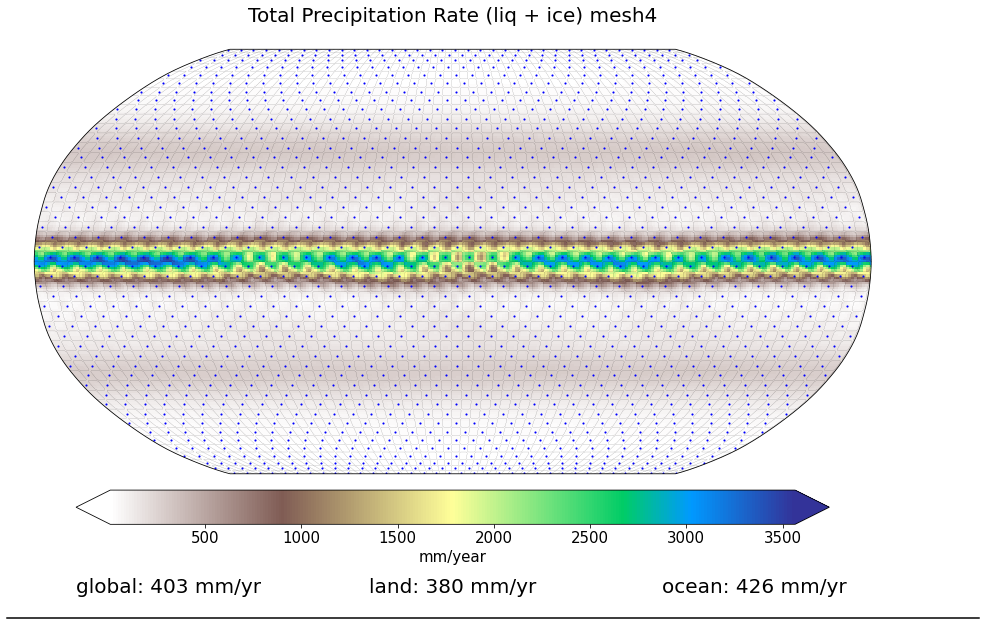

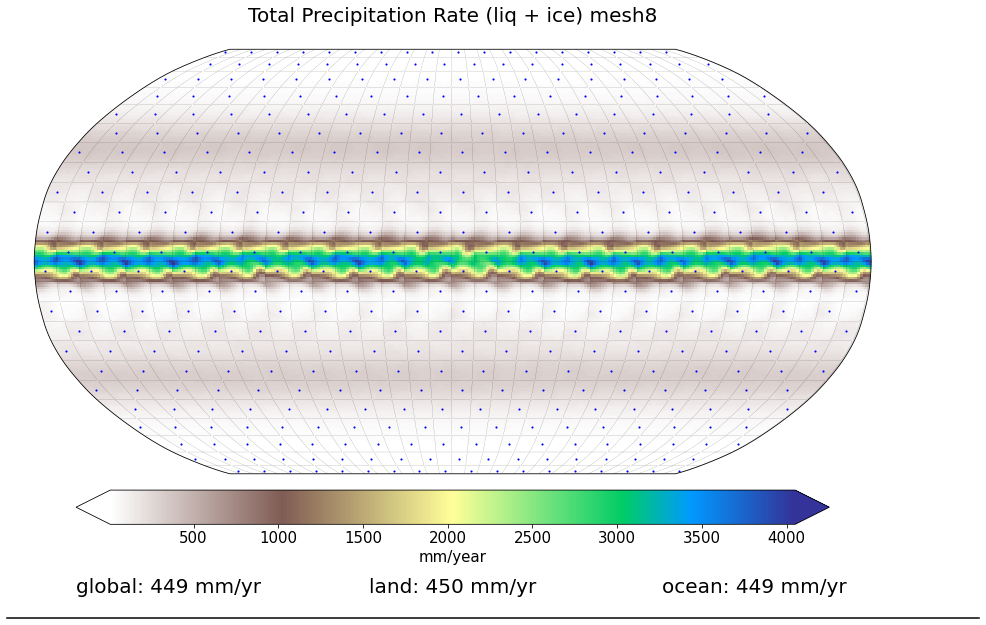

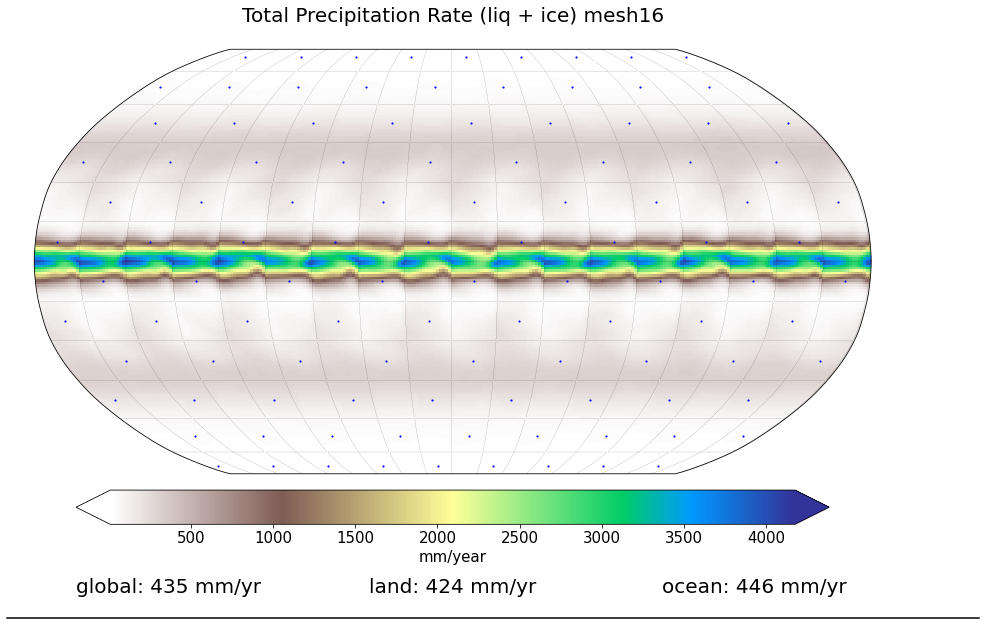

In [16]:
# Overall: plots separately the total precipitation rate for each experiment

for case in config:

    # Groups the case's atmospheric time series dictionary by year, calculates the mean
    ds_case = ts_dict_atm[case].groupby('time.year').mean('time')

    # Calculates the value of the total precipitation rate
    mapdata = (ds_case['PRECC'].mean('year') + ds_case['PRECL'].mean('year')) *86400*365.25*1000 # Convert to m/year

    # Collects the mesh data to select ocean/land values
    mask = mesh_dict[case]['mask'].values
    # Uses the mean function
    gm = (mean(ds_case, mask, 'PRECC')[0] + mean(ds_case, mask, 'PRECL')[0])
    lm = (mean(ds_case, mask, 'PRECC')[1] + mean(ds_case, mask, 'PRECL')[1])
    om = (mean(ds_case, mask, 'PRECC')[2] + mean(ds_case, mask, 'PRECL')[2])
    
    # Sets the plot's title
    ttl = 'Total Precipitation Rate (liq + ice) %s'%(case)

    # Sets the cmap colour
    cmap = plt.cm.get_cmap('terrain_r')
    clim = [0,5.5e-8*86400*365.25*1000]

    # Uses the quick_map function (defined previously) to create the plot
    fig, ax, cs, cbar, cm = quick_map(mapdata,mapdata.lat,mapdata.lon,mesh_dict[case],title=ttl,cb_ttl='mm/year',
              cmap=cmap,clim=None,
                  filepath=None,show=None,close=None,sigmask=None,p=None,
                  do_zonal=None,
                  outside_color = None, outside_val = None,extend='both')
    
    # Annotates the subplot with the global mean, land mean, and ocean mean
    ax.text(0.05, -0.28, 'global: %1.0f mm/yr'%gm, transform=ax.transAxes, fontsize=20)
    ax.text(0.4, -0.28, 'land: %1.0f mm/yr'%lm, transform=ax.transAxes, fontsize=20)
    ax.text(0.75, -0.28, 'ocean: %1.0f mm/yr'%om, transform=ax.transAxes, fontsize=20)

    plt.show()
    plt.close()

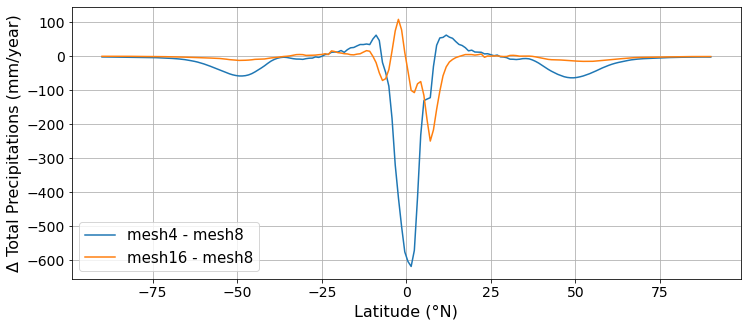

In [17]:
# Overall: compares the total precipitation rate of each patch size

plt.figure(figsize=(12,5))

# Calculates the reference case
ds_8 = ts_dict_atm['mesh8'].groupby('time.year').mean('time')
ref = (ds_8['PRECC'].mean('year').mean('lon') + ds_8['PRECL'].mean('year').mean('lon')) * 86400*365.25*1000

for case in ['mesh4','mesh16'] :
    # Groups the case's atmospheric time series dictionary by year, calculates the mean
    ds_case = ts_dict_atm[case].groupby('time.year').mean('time')

    # Calculates the value of humidity integrated vertically (altitude)
    mapdata = (ds_case['PRECC'].mean('year').mean('lon') + ds_case['PRECL'].mean('year').mean('lon'))*86400*365.25*1000 - ref
    
    plt.plot(mapdata.lat,mapdata,label=f'{case} - mesh8')

plt.grid()
plt.xlabel('Latitude (°N)',fontsize=16)
plt.ylabel('Δ Total Precipitations (mm/year)',fontsize=16)
plt.tick_params(axis='both', labelsize=14)
plt.legend(fontsize=15)

plt.show()
plt.close()

# **Snow rate (Water Equivalent)**

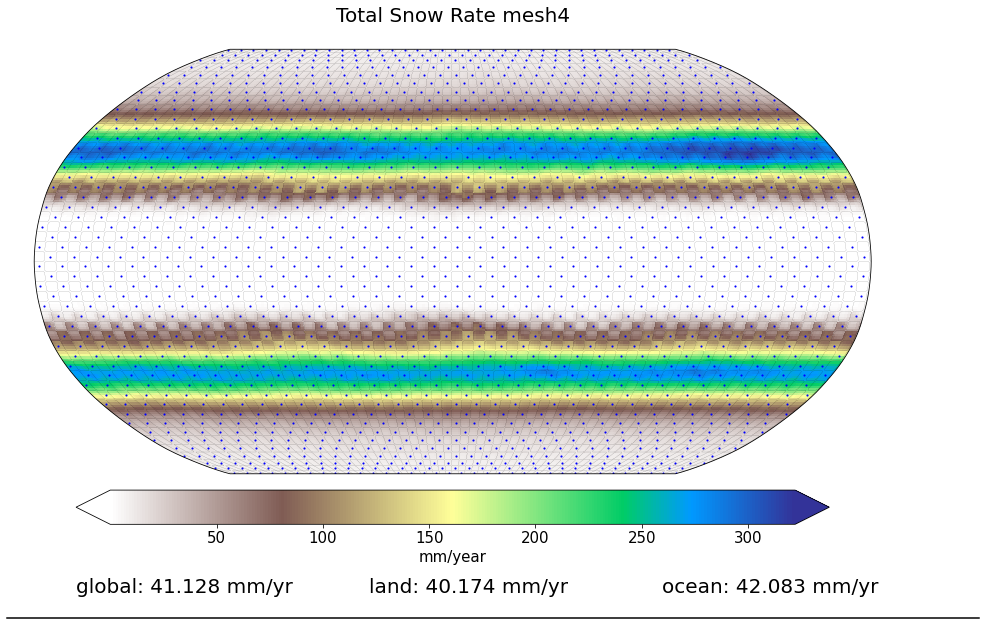

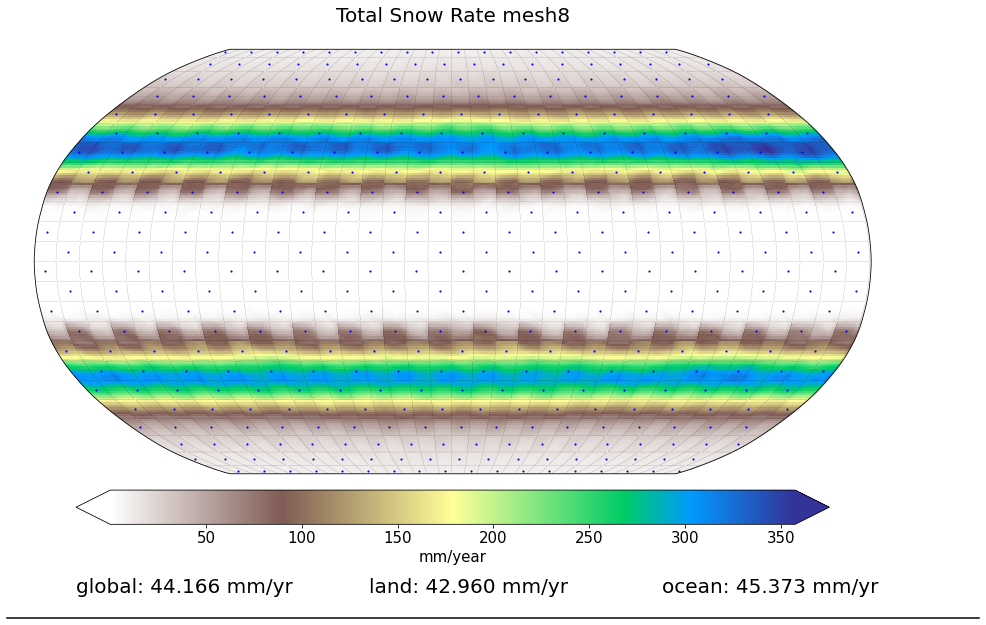

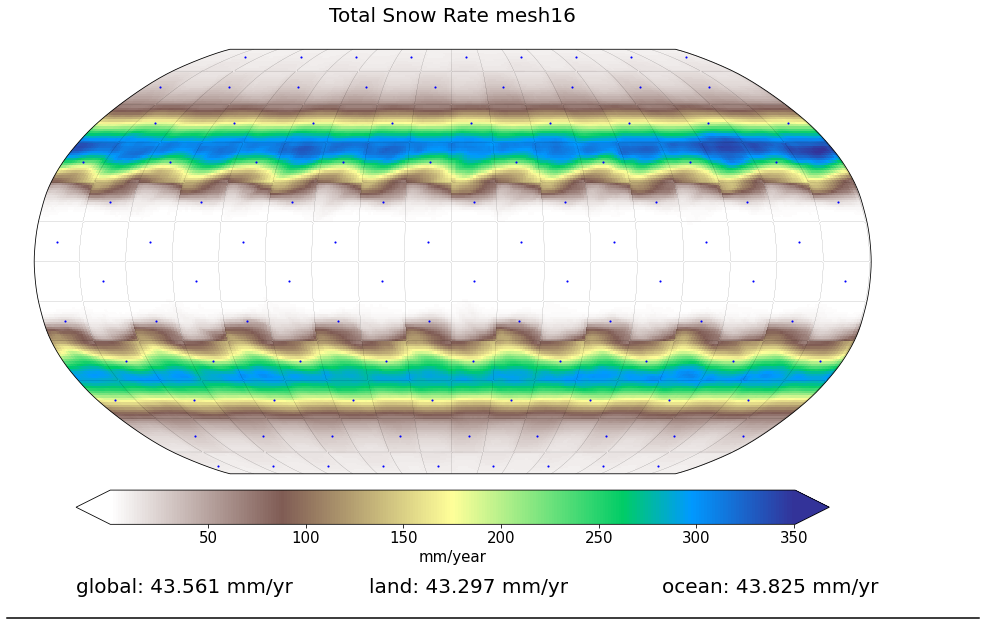

In [18]:
# Overall: plots separately the total snow rate for each case using the quick_map function defined previously

for case in config:
    # Groups the case's atmospheric time series dictionary by year, calculates the mean
    ds_case = ts_dict_atm[case].groupby('time.year').mean('time')

    # Calculates the value of total snow rate and converts it to mm/year
    mapdata = ds_case['PRECSC'].mean('year') + ds_case['PRECSL'].mean('year')
    mapdata = mapdata*86400*365.25*1000 # Convert to mm/year

    # Collects the mesh data to select ocean/land values
    mask = mesh_dict[case]['mask'].values

    # Uses the mean function
    gm = (mean(ds_case, mask, 'PRECSC')[0] + mean(ds_case, mask, 'PRECSL')[0]) / 2
    lm = (mean(ds_case, mask, 'PRECSC')[1] + mean(ds_case, mask, 'PRECSL')[1]) / 2
    om = (mean(ds_case, mask, 'PRECSC')[2] + mean(ds_case, mask, 'PRECSL')[2]) / 2
    
    # Sets the plot's title
    ttl = 'Total Snow Rate %s'%(case)

    # Sets the cmap colour
    cmap = plt.cm.get_cmap('terrain_r')
    clim = [0,250]

    # Uses the quick_map function (defined previously) to create the plot
    fig, ax, cs, cbar, cm = quick_map(mapdata,mapdata.lat,mapdata.lon,mesh_dict[case],title=ttl,cb_ttl='mm/year',
              cmap=cmap,clim=None,
                  filepath=None,show=None,close=None,sigmask=None,p=None,
                  do_zonal=None,
                  outside_color = None, outside_val = None,extend='both')

    # Annotates the subplot with the global mean, land mean, and ocean mean
    ax.text(0.05, -0.28, 'global: %1.3f mm/yr'%gm, transform=ax.transAxes, fontsize=20)
    ax.text(0.4, -0.28, 'land: %1.3f mm/yr'%lm, transform=ax.transAxes, fontsize=20)
    ax.text(0.75, -0.28, 'ocean: %1.3f mm/yr'%om, transform=ax.transAxes, fontsize=20)

    plt.show()
    plt.close()

# **Focus (Subtropics)**
The particularity of this plot is the wind representation. The arrows correspond to the sum of the meridional and zonal winds, meaning that they correspond to the air circulation (here, it is the circulation at the lowest layer of the atmosphere).

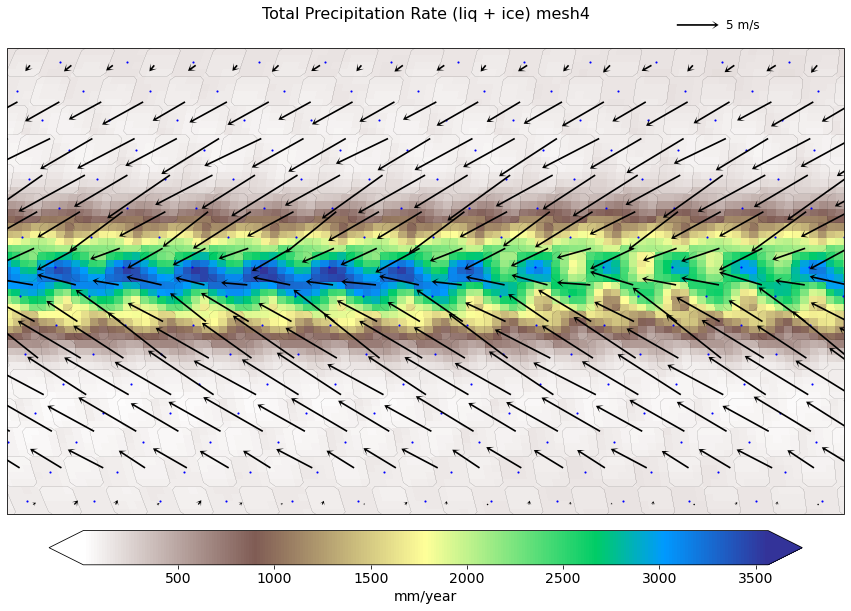

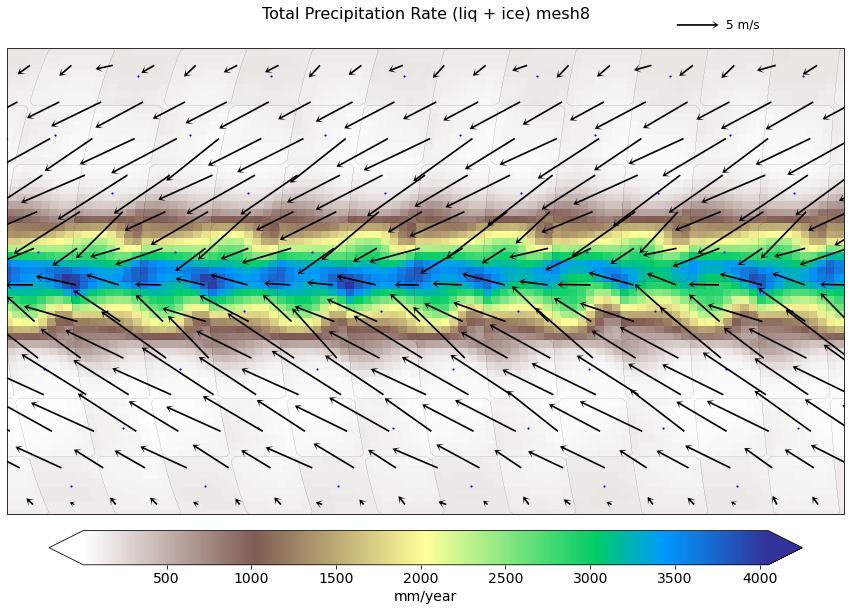

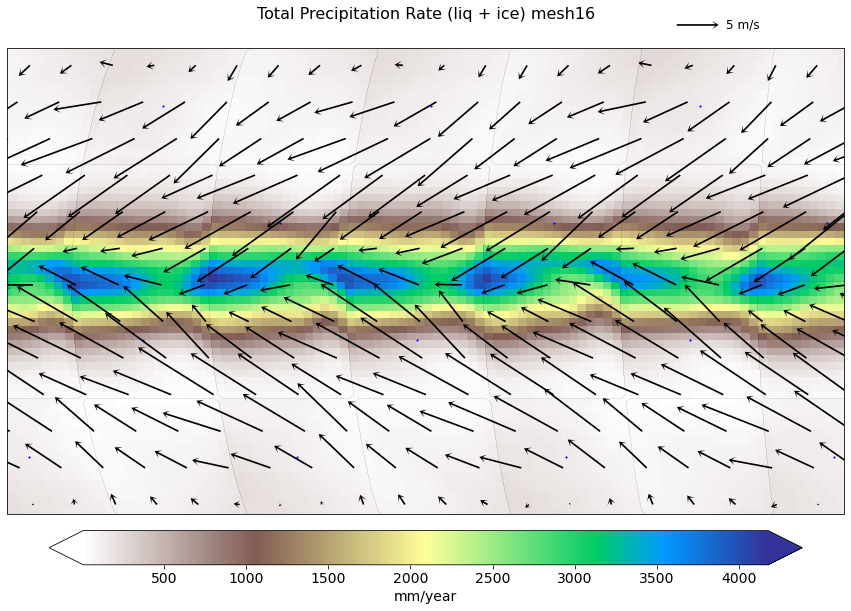

In [19]:
# Overall: plots the total precipitation rate over the subtropics and the wind circulation of the lowest atmospheric layer

for case in config:
    # Groups the case's atmospheric time series dictionary by year, calculates the mean
    ds_case = ts_dict_atm[case].groupby('time.year').mean('time')

    # Calculates the value of humidity integrated vertically (altitude)
    mapdata = (ds_case['PRECC'].mean('year') + ds_case['PRECL'].mean('year')) *86400*365.25*1000 # Converts to mm/year
    
    # Sets the plot's title
    ttl = 'Total Precipitation Rate (liq + ice) %s'%(case)

    # Sets the cmap colour
    cmap = plt.cm.get_cmap('terrain_r')

    # Uses the quick_map function (defined previously) to create the plot
    fig, ax, cs, cbar, cm = quick_trop(mapdata,mapdata.lat,mapdata.lon,mesh_dict[case],title=ttl,cb_ttl='mm/year',
              cmap=cmap,clim=None,
                  filepath=None,show=None,close=None,sigmask=None,p=None,
                  do_zonal=None,
                  outside_color = None, outside_val = None,extend='both')

    # Collects the meridional and zonal wind variables at the lowest layer of the atmosphere
    V = ds_case['V'].mean('year').isel(lev=-1)
    U = ds_case['U'].mean('year').isel(lev=-1)

    # Adds a cyclic point to ensure a smooth plot
    cyclic_U, cyclic_lons = add_cyclic_point(U, coord=U.lon)
    cyclic_V, _ = add_cyclic_point(V, coord=V.lon)

    skip   = 5
    lons   = cyclic_lons[::skip]
    lats   = U.lat.values[::skip]
    U_plot = cyclic_U[::skip, ::skip]
    V_plot = cyclic_V[::skip, ::skip]

    # Draws the wind vectors
    q = cs = ax.quiver(lons, lats, U_plot, V_plot, color='black', scale=100, width=0.002, headwidth=5, headlength=4, headaxislength=2, transform=ccrs.PlateCarree())

    # Adds a legend to observe the wind intensity
    ax.quiverkey(q, X=0.85, Y=1.05, U=5, label='5 m/s', labelpos='E', fontproperties={'size': 12}, coordinates='axes')

    plt.show()
    plt.close()

# **Intra-cell comparison**

In [20]:
print('This code calculates the difference intra-cell for each mesh for the cell closest to the equator (NH) at a random longitude.')

for case in config:
    ds_case = ts_dict_atm[case].groupby('time.year').mean('time')
    mapdata = (ds_case['PRECL'].mean('year') + ds_case['PRECC'].mean('year')) * 86400*365.25*1000

    mask = mesh_dict[case]['mask'].values
    data_land = mapdata.where(mask == 1)
    data_ocean = mapdata.where(mask == 0)

    if case == 'mesh4' :
        land = data_land[96:100,8:12]
        ocean = data_ocean[96:100,4:8]
        print(f'Mesh4: land max/min = {float(land.max()):.1f}/{float(land.min()):.1f} mm/yr & ocean max/min = {float(ocean.max()):.1f}/{float(ocean.min()):.1f} mm/yr')

    elif case == 'mesh8' :
        land = data_land[96:104,:8]
        ocean = data_ocean[96:104,8:16]
        print(f'Mesh8: land max/min = {float(land.max()):.1f}/{float(land.min()):.1f} mm/yr & ocean max/min = {float(ocean.max()):.1f}/{float(ocean.min()):.1f} mm/yr')

    elif case == 'mesh16' :
        land = data_land[96:112,0:16]
        ocean = data_ocean[96:112,16:32]
        print(f'Mesh16: land max/min = {float(land.max()):.1f}/{float(land.min()):.1f} mm/yr & ocean max/min = {float(ocean.max()):.1f}/{float(ocean.min()):.1f} mm/yr')

This code calculates the difference intra-cell for each mesh for the cell closest to the equator (NH) at a random longitude.
Mesh4: land max/min = 1883.2/1179.1 mm/yr & ocean max/min = 2593.9/2123.0 mm/yr
Mesh8: land max/min = 3360.1/927.9 mm/yr & ocean max/min = 3476.3/1139.7 mm/yr
Mesh16: land max/min = 3700.6/61.2 mm/yr & ocean max/min = 3877.1/28.5 mm/yr


In [21]:
print('This code calculates the difference intra-cell for each mesh for the cell closest to the equator (SH) at a random longitude.')

for case in config:
    ds_case = ts_dict_atm[case].groupby('time.year').mean('time')
    mapdata = (ds_case['PRECL'].mean('year') + ds_case['PRECC'].mean('year')) * 86400*365.25*1000

    mask = mesh_dict[case]['mask'].values
    data_land = mapdata.where(mask == 1)
    data_ocean = mapdata.where(mask == 0)

    if case == 'mesh4' :
        land = data_land[92:96,4:8]
        ocean = data_ocean[92:96,8:12]
        print(f'Mesh4: land max/min = {float(land.max()):.1f}/{float(land.min()):.1f} mm/yr & ocean max/min = {float(ocean.max()):.1f}/{float(ocean.min()):.1f} mm/yr')

    elif case == 'mesh8' :
        land = data_land[88:96,8:16]
        ocean = data_ocean[88:96,:8]
        print(f'Mesh8: land max/min = {float(land.max()):.1f}/{float(land.min()):.1f} mm/yr & ocean max/min = {float(ocean.max()):.1f}/{float(ocean.min()):.1f} mm/yr')

    elif case == 'mesh16' :
        land = data_land[80:96,16:32]
        ocean = data_ocean[80:96,:16]
        print(f'Mesh16: land max/min = {float(land.max()):.1f}/{float(land.min()):.1f} mm/yr & ocean max/min = {float(ocean.max()):.1f}/{float(ocean.min()):.1f} mm/yr')

This code calculates the difference intra-cell for each mesh for the cell closest to the equator (SH) at a random longitude.
Mesh4: land max/min = 1928.1/880.2 mm/yr & ocean max/min = 2370.1/1429.3 mm/yr
Mesh8: land max/min = 3057.9/545.9 mm/yr & ocean max/min = 3314.0/646.9 mm/yr
Mesh16: land max/min = 3746.0/27.5 mm/yr & ocean max/min = 3770.5/21.4 mm/yr
